# 2026-04-23 Axial organization

## Summary

In this notebook, we are trying to solve the issue of axial structure on VLPs to enable chemical modification. This issue is given by the fact that a simple SASA calculation does not allow us to know whether we are placing a chemical modification inside or outside. 

To move beyond basic SASA analysis, we will also consider the distance of every $C\alpha$ atom to the geometric center of the scaffold using MDAnalysis. Then we will  normalize these distances by subtracting the mean scaffold distance, which allows us to classify residues as 'inner' (negative deviation) or 'outer' (positive deviation). Also, we will filter for lysines that meet a threshold of SASA > 50. 

In the end, we will generate a table,lysine-choices.csv, containing the lysines that can be modified in each of our VLP scaffolds. It includes the following data for each candidate:
- Scaffold name and chain
- Residue number
- SASA score
- Location 

## Dependencies

In [1]:
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
import MDAnalysis as mda
import pandas as pd
import yaml
import freesasa
import warnings
warnings.filterwarnings('ignore')  # Suppress all warnings
freesasa.setVerbosity(0)

/Users/chloehjj/PCE26/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Functions

In [2]:
scaffolds = yaml.safe_load(open("../data/scaffolds/index.yaml"))

In [3]:
pois = yaml.safe_load(open("../data/poi/index.yaml"))

In [4]:
def compute_sasa(
    pdb_path: str
) -> dict[str, list[dict]]:
    """Return exposed GLU/ASP and LYS residues sorted by SASA (descending)."""
    structure = freesasa.Structure(pdb_path)
    result = freesasa.calc(structure)
    residue_areas = result.residueAreas()

    out = []
    
    for chain_label, residues in residue_areas.items():
        for res_number, area in residues.items():
            
            entry = {
                "chain": chain_label,
                "residue_number": res_number,
                "residue_type": area.residueType,
                "sasa_total": round(area.total, 2),
                "sasa_side_chain": round(area.sideChain, 2),
                "relative_side_chain": round(area.relativeSideChain, 3),
            }

            out.append(entry)

    return pd.DataFrame.from_records(out)

sasa_df = []
for item in scaffolds:
    tmp_df = compute_sasa('../data/scaffolds/' + item["scaffold"])
    tmp_df['scaffold'] = item['name']
    sasa_df.append(tmp_df)
sasa_df = pd.concat(sasa_df)
sasa_df

,chain,residue_number,residue_type,sasa_total,sasa_side_chain,relative_side_chain,scaffold
0,A,217,GLY,90.78,0.00,NaN,adenovirus
1,A,218,ALA,70.23,39.36,0.607,adenovirus
2,A,219,ASP,72.80,59.63,0.594,adenovirus
3,A,220,GLY,33.84,0.00,NaN,adenovirus
4,A,221,VAL,21.91,16.85,0.153,adenovirus
...,...,...,...,...,...,...,...
1711,A,924,THR,21.76,18.21,0.185,glv
1712,A,925,PHE,4.26,1.75,0.011,glv
1713,A,926,LEU,28.95,11.08,0.079,glv
1714,A,927,ASP,92.03,53.31,0.531,glv


In [5]:
sasa_df_base = []
for item in pois:
    tmp_df2 = compute_sasa('../data/poi/' + item["poi"])
    tmp_df2['poi'] = item['name']
    sasa_df_base.append(tmp_df2)
sasa_df_base = pd.concat(sasa_df_base)
sasa_df_base

FreeSASA: warning: atom 'YCM  N  ' unknown, guessing element is ' N', and radius 1.550 A
FreeSASA: warning: atom 'YCM  CA ' unknown, guessing element is ' C', and radius 1.700 A
FreeSASA: warning: atom 'YCM  CB ' unknown, guessing element is ' C', and radius 1.700 A
FreeSASA: warning: atom 'YCM  SG ' unknown, guessing element is ' S', and radius 1.800 A
FreeSASA: warning: atom 'YCM  CD ' unknown, guessing element is ' C', and radius 1.700 A
FreeSASA: warning: atom 'YCM  CE ' unknown, guessing element is ' C', and radius 1.700 A
FreeSASA: warning: atom 'YCM  OZ1' unknown, guessing element is ' O', and radius 1.520 A
FreeSASA: warning: atom 'YCM  NZ2' unknown, guessing element is ' N', and radius 1.550 A
FreeSASA: warning: atom 'YCM  C  ' unknown, guessing element is ' C', and radius 1.700 A
FreeSASA: warning: atom 'YCM  O  ' unknown, guessing element is ' O', and radius 1.520 A


,chain,residue_number,residue_type,sasa_total,sasa_side_chain,relative_side_chain,poi
0,A,5,GLU,197.77,134.56,1.018,fel d 1
1,A,6,THR,44.54,36.71,0.372,fel d 1
2,A,7,CYS,1.29,0.00,0.000,fel d 1
3,A,8,PRO,59.15,54.70,0.499,fel d 1
4,A,9,ILE,3.36,2.84,0.021,fel d 1
...,...,...,...,...,...,...,...
334,A,326,VAL,99.42,82.03,0.743,crth
335,A,327,LEU,143.18,110.71,0.792,crth
336,A,328,VAL,108.06,95.64,0.866,crth
337,A,329,ASP,103.97,55.06,0.548,crth


In [6]:
amino_acid_properties = {
    "ALA": "Nonpolar",
    "VAL": "Nonpolar",
    "LEU": "Nonpolar",
    "ILE": "Nonpolar",
    "PHE": "Nonpolar",
    "TRP": "Nonpolar",
    "MET": "Nonpolar",
    "PRO": "Nonpolar",
    "GLY": "Nonpolar",
    "SER": "Polar",
    "THR": "Polar",
    "CYS": "Polar",
    "TYR": "Polar",
    "ASN": "Polar",
    "GLN": "Polar",
    "LYS": "Basic",
    "ARG": "Basic",
    "HIS": "Basic",
    "ASP": "Acidic",
    "GLU": "Acidic"
}

sasa_df['residue_family'] = sasa_df['residue_type'].map(amino_acid_properties)

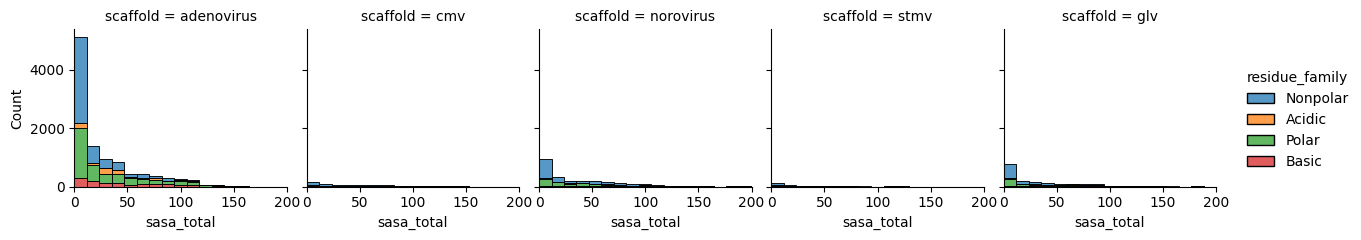

In [7]:
sns.displot(data=sasa_df, 
            x = 'sasa_total',
            bins = 20,
            col = 'scaffold',
            hue = 'residue_family',
            multiple = 'stack',
            height = 2.5,
            aspect = 1).set(xlim = (0,200))

In [8]:
def compute_distance_to_center(
    pdb_path: str
) -> dict[str, list[dict]]:
    """Return exposed GLU/ASP and LYS residues sorted by SASA (descending)."""
    structure = mda.Universe(pdb_path)
    positions = structure.atoms.select_atoms("name NZ").positions
    distances = np.linalg.norm(positions, axis=1)
    resnums = structure.atoms.select_atoms("name NZ").resnums
    resnames = structure.atoms.select_atoms("name NZ").resnames
    chids = structure.atoms.select_atoms("name NZ").chainIDs
    u = pd.DataFrame.from_dict(
        dict(chain=chids, residue_number=resnums, residue_type=resnames, distance=distances)
    )
    u.residue_number = u.residue_number.astype(str)
    return u

distances_df = []
for item in scaffolds:
    tmp_df = compute_distance_to_center('../data/scaffolds/' + item["scaffold"])
    tmp_df['scaffold'] = item['name']
    distances_df.append(tmp_df)
distances_df = pd.concat(distances_df)
distances_df

,chain,residue_number,residue_type,distance,scaffold
0,A,258,LYS,115.959923,adenovirus
1,A,309,LYS,85.697845,adenovirus
2,A,310,LYS,82.024193,adenovirus
3,A,314,LYS,87.586128,adenovirus
4,A,321,LYS,104.766266,adenovirus
...,...,...,...,...,...
2515,A,584,LYS,773.351868,glv
2516,A,663,LYS,770.027588,glv
2517,A,698,LYS,781.717041,glv
2518,A,774,LYS,748.993347,glv


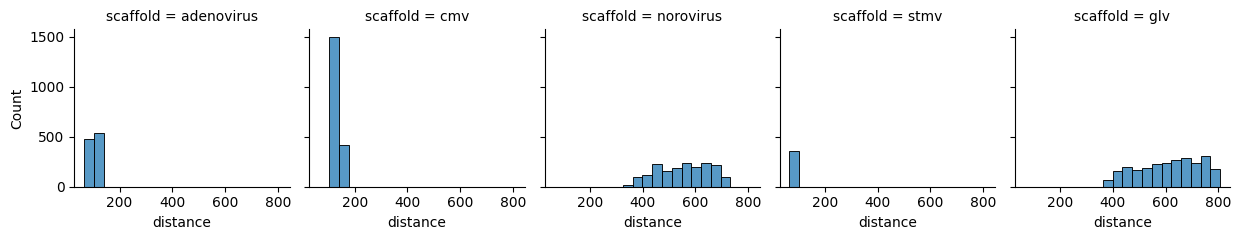

In [9]:
sns.displot(data = distances_df,
            x = 'distance',
            bins = 20,
            col = 'scaffold',
            multiple = 'stack',
            height = 2.5,
            aspect = 1)

In [10]:
full_df = pd.merge(distances_df, sasa_df)

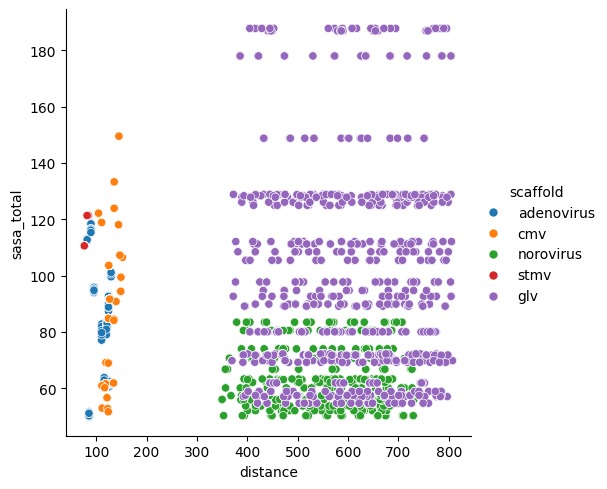

In [11]:
sns.relplot(full_df.query('residue_type == "LYS"').query('sasa_total > 50'),
            x = 'distance', 
            y = 'sasa_total',
            hue = 'scaffold')

In [12]:
full_df = pd.merge(
    full_df, 
    full_df.groupby('scaffold', as_index=False)['distance'].mean(), 
    suffixes=['', '_mean'], on=['scaffold']
)
full_df['distance_norm'] = full_df['distance'] - full_df['distance_mean']

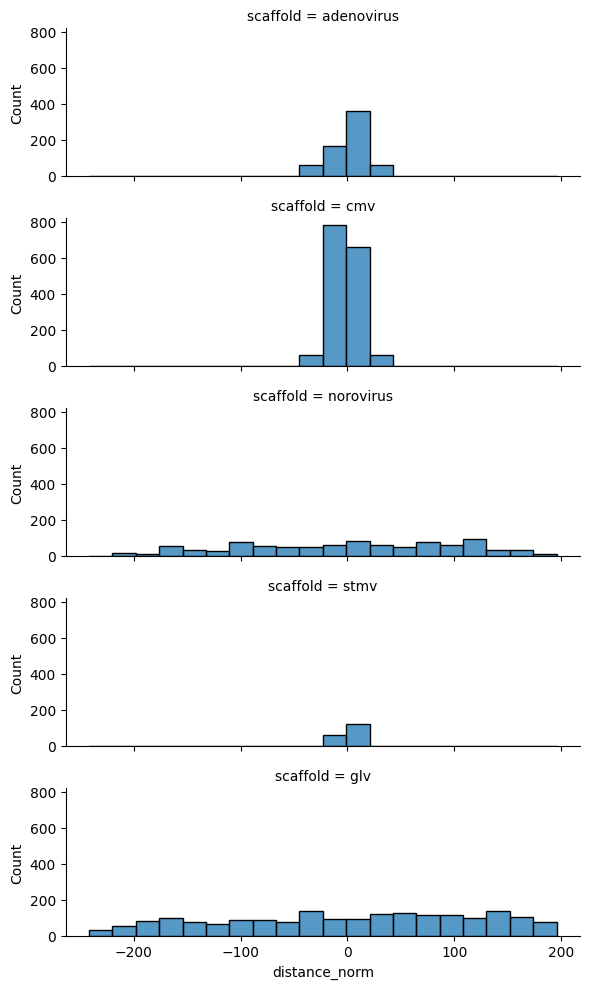

In [13]:
sns.displot(full_df.query('residue_type == "LYS"').query('sasa_total > 50'),
            x = 'distance_norm',
            row = 'scaffold',
            bins = 20,
            multiple = 'stack',
            height = 2,
            aspect = 3)

In [14]:
full_df['location'] = full_df['distance_norm'].apply(lambda x: 'outer' if x > 0 else 'inner')
full_df

,chain,residue_number,residue_type,distance,scaffold,sasa_total,sasa_side_chain,relative_side_chain,residue_family,distance_mean,distance_norm,location
0,A,258,LYS,115.959923,adenovirus,63.34,63.34,0.389,Basic,106.695816,9.264107,outer
1,A,309,LYS,85.697845,adenovirus,50.47,49.91,0.306,Basic,106.695816,-20.997971,inner
2,A,310,LYS,82.024193,adenovirus,113.23,113.20,0.695,Basic,106.695816,-24.671623,inner
3,A,314,LYS,87.586128,adenovirus,45.70,45.70,0.280,Basic,106.695816,-19.109688,inner
4,A,321,LYS,104.766266,adenovirus,5.14,5.14,0.032,Basic,106.695816,-1.929550,inner
...,...,...,...,...,...,...,...,...,...,...,...,...
7615,A,584,LYS,773.351868,glv,58.88,54.73,0.336,Basic,611.495789,161.856079,outer
7616,A,663,LYS,770.027588,glv,128.35,122.92,0.754,Basic,611.495789,158.531799,outer
7617,A,698,LYS,781.717041,glv,69.21,62.75,0.385,Basic,611.495789,170.221252,outer
7618,A,774,LYS,748.993347,glv,54.69,48.03,0.295,Basic,611.495789,137.497559,outer


In [15]:
u = mda.Universe('../data/scaffolds/' + scaffolds[0]["scaffold"])

In [16]:
u.atoms.occupancies = 0.0
x = scaffolds[0]['name']
for k, item in full_df.query('scaffold == @x').iterrows():

    selection = u.select_atoms('chainID {0} and resnum {1}'.format(item.chain, item.residue_number))
    if item.location == 'inner':
        selection.atoms.occupancies = -1
    if item.location == 'outer':
        selection.atoms.occupancies = 1

u

<Universe with 250560 atoms>

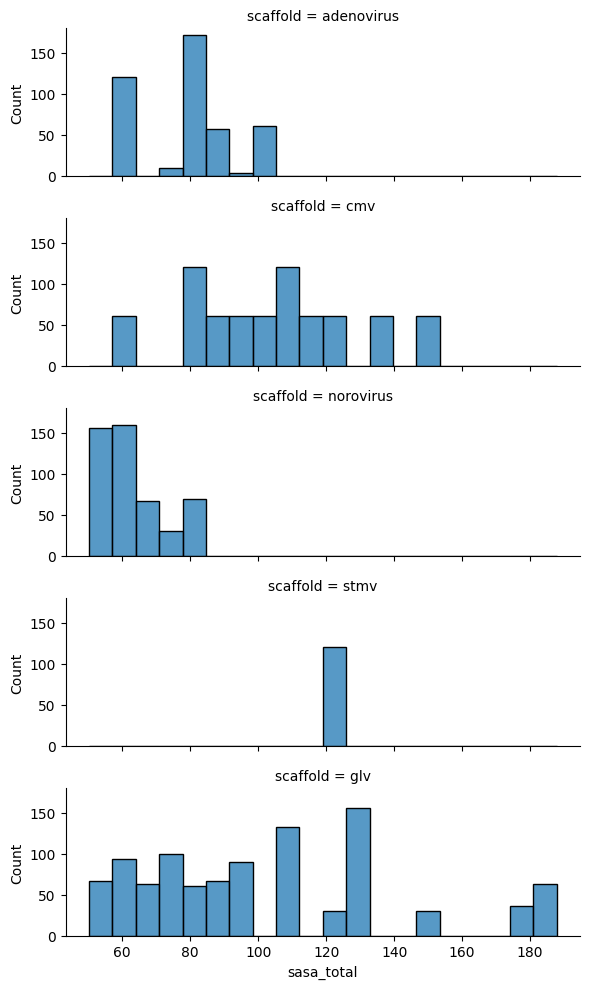

In [17]:
sns.displot(full_df.query('residue_type == "LYS"').query('sasa_total > 50').query('location == "outer"'),
            x = 'sasa_total',
            row = 'scaffold',
            bins = 20,
            multiple = 'stack',
            height = 2,
            aspect = 3)

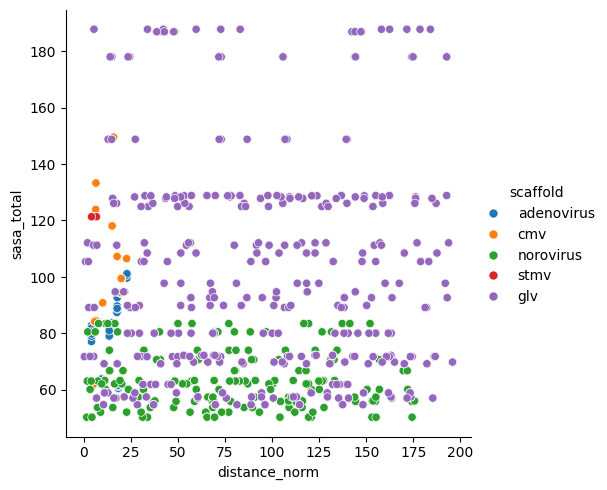

In [18]:
sns.relplot(full_df.query('residue_type == "LYS"').query('sasa_total > 50').query('location == "outer"'),
            x = 'distance_norm', 
            y = 'sasa_total',
            hue = 'scaffold')

In [19]:
u.atoms.write("foo.pdb")

In [20]:
full_df.query('residue_type == "LYS"').query('sasa_total > 50').to_csv('../data/scaffolds/lysine-choices.csv')

In [21]:
sasa_df_base.query('residue_type == "ASP" or residue_type == "GLU"').to_csv('../data/poi/base-choices.csv')

In [22]:
base_candi = []

for item in pois:
    protein = (item['name'])
    best_base = (sasa_df_base.query('poi == @protein').query('residue_type == "ASP" or residue_type == "GLU"').sort_values('sasa_total', ascending = False).head(1))
    base_candi.append(best_base)

base_candi_df = pd.concat(base_candi)
base_candi_df
base_candi_df.to_csv('../data/poi/best-bases.csv')

In [43]:
sasa_df_base.query('poi=="pru p 3"')

,chain,residue_number,residue_type,sasa_total,sasa_side_chain,relative_side_chain,poi
0,A,0,MET,182.19,132.07,0.874,pru p 3
1,A,1,ILE,9.65,5.31,0.040,pru p 3
2,A,2,THR,76.25,71.39,0.724,pru p 3
3,A,3,CYS,42.45,36.47,0.407,pru p 3
4,A,4,GLY,41.89,0.00,NaN,pru p 3
...,...,...,...,...,...,...,...
179,B,87,CYS,3.33,1.66,0.019,pru p 3
180,B,88,ALA,80.26,51.93,0.801,pru p 3
181,B,89,THR,102.12,72.74,0.737,pru p 3
182,B,90,VAL,17.00,7.31,0.066,pru p 3


In [24]:
lys_candi = []

for item in scaffolds:
    virus = (item['name'])

    best_lys = (full_df.query('location == "outer" and scaffold == @virus and residue_type == "LYS"').sort_values('distance', ascending = False).head(1))

    lys_candi.append(best_lys)

lys_candi_df = pd.concat(lys_candi)
lys_candi_df
                
   

,chain,residue_number,residue_type,distance,scaffold,sasa_total,sasa_side_chain,relative_side_chain,residue_family,distance_mean,distance_norm,location
552,M,533,LYS,129.715424,adenovirus,99.94,99.19,0.609,Basic,106.695816,23.019608,outer
1917,A,79,LYS,152.101883,cmv,106.50,88.91,0.546,Basic,129.367035,22.734848,outer
3765,B,1348,LYS,730.747559,norovirus,56.03,54.43,0.334,Basic,555.088379,175.659180,outer
4813,A,54,LYS,84.522987,stmv,121.34,112.01,0.687,Basic,77.851349,6.671638,outer
7415,B,167,LYS,807.334900,glv,69.80,65.22,0.400,Basic,611.495789,195.839111,outer


In [25]:
import pandas as pd

lys_candi = []

for item in scaffolds:
    virus = item["name"]

    sub_df = full_df.query(
        'location == "outer" and scaffold == @virus and residue_type == "LYS"'
    ).copy()

    if sub_df.empty:
        continue

    # Min-Max boundaries
    sasa_min, sasa_max = sub_df["sasa_total"].min(), sub_df["sasa_total"].max()
    dist_min, dist_max = sub_df["distance"].min(), sub_df["distance"].max()

    sasa_denom = sasa_max - sasa_min if sasa_max != sasa_min else 1e-5
    dist_denom = dist_max - dist_min if dist_max != dist_min else 1e-5

    # Normalize (0 to 1)
    sub_df["sasa_norm"] = (sub_df["sasa_total"] - sasa_min) / sasa_denom
    sub_df["dist_norm"] = (sub_df["distance"] - dist_min) / dist_denom

    # Both are "higher is better", so we do NOT invert the distance!
    # Applying your 2:1 importance ratio here
    sub_df["composite_score"] = (
        (2 * sub_df["dist_norm"]) + (1 * sub_df["sasa_norm"])
    ) / 3

    # Grab the absolute highest composite score per scaffold
    best_lys = sub_df.sort_values("composite_score", ascending=False).head(1)
    lys_candi.append(best_lys)

lys_candi_df = pd.concat(lys_candi).reset_index(drop=True)
lys_candi_df
                
lys_candi_df.to_csv('../data/scaffolds/lysine-candidates.csv')

In [26]:
lys_candi_df

,chain,residue_number,residue_type,distance,scaffold,sasa_total,sasa_side_chain,relative_side_chain,residue_family,distance_mean,distance_norm,location,sasa_norm,dist_norm,composite_score
0,I,533,LYS,129.648880,adenovirus,101.32,100.50,0.617,Basic,106.695816,22.953064,outer,0.999635,0.996491,0.997539
1,A,79,LYS,152.101883,cmv,106.50,88.91,0.546,Basic,129.367035,22.734848,outer,0.640752,1.000000,0.880251
2,C,2348,LYS,726.917908,norovirus,66.75,61.58,0.378,Basic,555.088379,171.829529,outer,0.797822,0.978056,0.917978
3,A,54,LYS,84.522987,stmv,121.34,112.01,0.687,Basic,77.851349,6.671638,outer,1.000000,1.000000,1.000000
4,B,433,LYS,804.243103,glv,178.01,138.57,0.850,Basic,611.495789,192.747314,outer,0.943890,0.984190,0.970756
